# Proof-of-Concept 4-Parameter Model K-Fold Cross-Validation

This notebook uses K-Fold Cross Validation on a small proof-of-concept emulator that predicts the **binned kSZ angular power spectrum ($D_\ell$)** using 4 reionization params ($z_{mean}$, $\alpha$, $k_b$, $b_0$).

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

plt.rc("figure", figsize=(6, 4), dpi=150)

from reionemu import (
    DataLoaderConfig,
    FitConfig,
    FourParamEmulator,
    KFoldConfig,
    kfold_cross_validate,
    load_training_arrays,
)

## Condensed HDF5 Path
The condensed v6 simulation dataset is constructed with: $Y = \ln(D_\ell)$

In [4]:
H5_PATH = Path("../data/processed/condensed_v6.h5").resolve()

## Define Model | Optimizer | Configs

In [5]:
def model_builder() -> torch.nn.Module:
    return FourParamEmulator()


def optimizer_builder(model: torch.nn.Module) -> torch.optim.Optimizer:
    return torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)


loss_fn = torch.nn.MSELoss()

dlcfg = DataLoaderConfig(
    batch_size=32, seed=42, shuffle_train=True, normalize_X=True, normalize_Y=False
)

fitcfg = FitConfig(
    epochs=200, device="mps", early_stopping_patience=50, gradient_clipping=None
)

kcfg = KFoldConfig(k=5, seed=42, return_histories=True)

## Run K-Fold Cross Validation

In [6]:
result = kfold_cross_validate(
    H5_PATH,
    model_builder=model_builder,
    optimizer_builder=optimizer_builder,
    loss_fn=loss_fn,
    kfold_config=kcfg,
    dl_config=dlcfg,
    fit_config=fitcfg,
)


=== Fold 1/5 | train=800 val=200 ===
Epoch 001: train=0.316887, val=0.276879
Epoch 002: train=0.252400, val=0.220450
Epoch 003: train=0.187770, val=0.147172
Epoch 004: train=0.112354, val=0.073404
Epoch 005: train=0.053792, val=0.035862
Epoch 006: train=0.028891, val=0.023342
Epoch 007: train=0.020690, val=0.019151
Epoch 008: train=0.017491, val=0.016798
Epoch 009: train=0.015429, val=0.015388
Epoch 010: train=0.013989, val=0.013994
Epoch 011: train=0.012677, val=0.013077
Epoch 012: train=0.011668, val=0.012129
Epoch 013: train=0.010728, val=0.011439
Epoch 014: train=0.010035, val=0.010863
Epoch 015: train=0.009410, val=0.010263
Epoch 016: train=0.008968, val=0.009923
Epoch 017: train=0.008463, val=0.009675
Epoch 018: train=0.008065, val=0.009361
Epoch 019: train=0.007606, val=0.009067
Epoch 020: train=0.007335, val=0.008721
Epoch 021: train=0.007121, val=0.008346
Epoch 022: train=0.006947, val=0.008132
Epoch 023: train=0.006585, val=0.008237
Epoch 024: train=0.006547, val=0.007752
Ep

## K-Fold CV Results

In [7]:
print(result.keys())
print(f"Min Validation Loss Per Fold: {result['fold_best_val']}")
print(f"Mean Validation Loss (MSE): {result['mean_best_val']}")
print(f"STD Validation Loss: {result['std_best_val']}")

dict_keys(['ell', 'fold_best_val', 'mean_best_val', 'std_best_val', 'models', 'norms', 'val_indices', 'histories'])
Min Validation Loss Per Fold: [0.0042192706046625976, 0.0049407765828073024, 0.0036632135696709157, 0.0036043839063495398, 0.0039002045802772043]
Mean Validation Loss (MSE): 0.004065569848753512
STD Validation Loss: 0.0005457882992760563


## Plot Learning Curves Per Fold

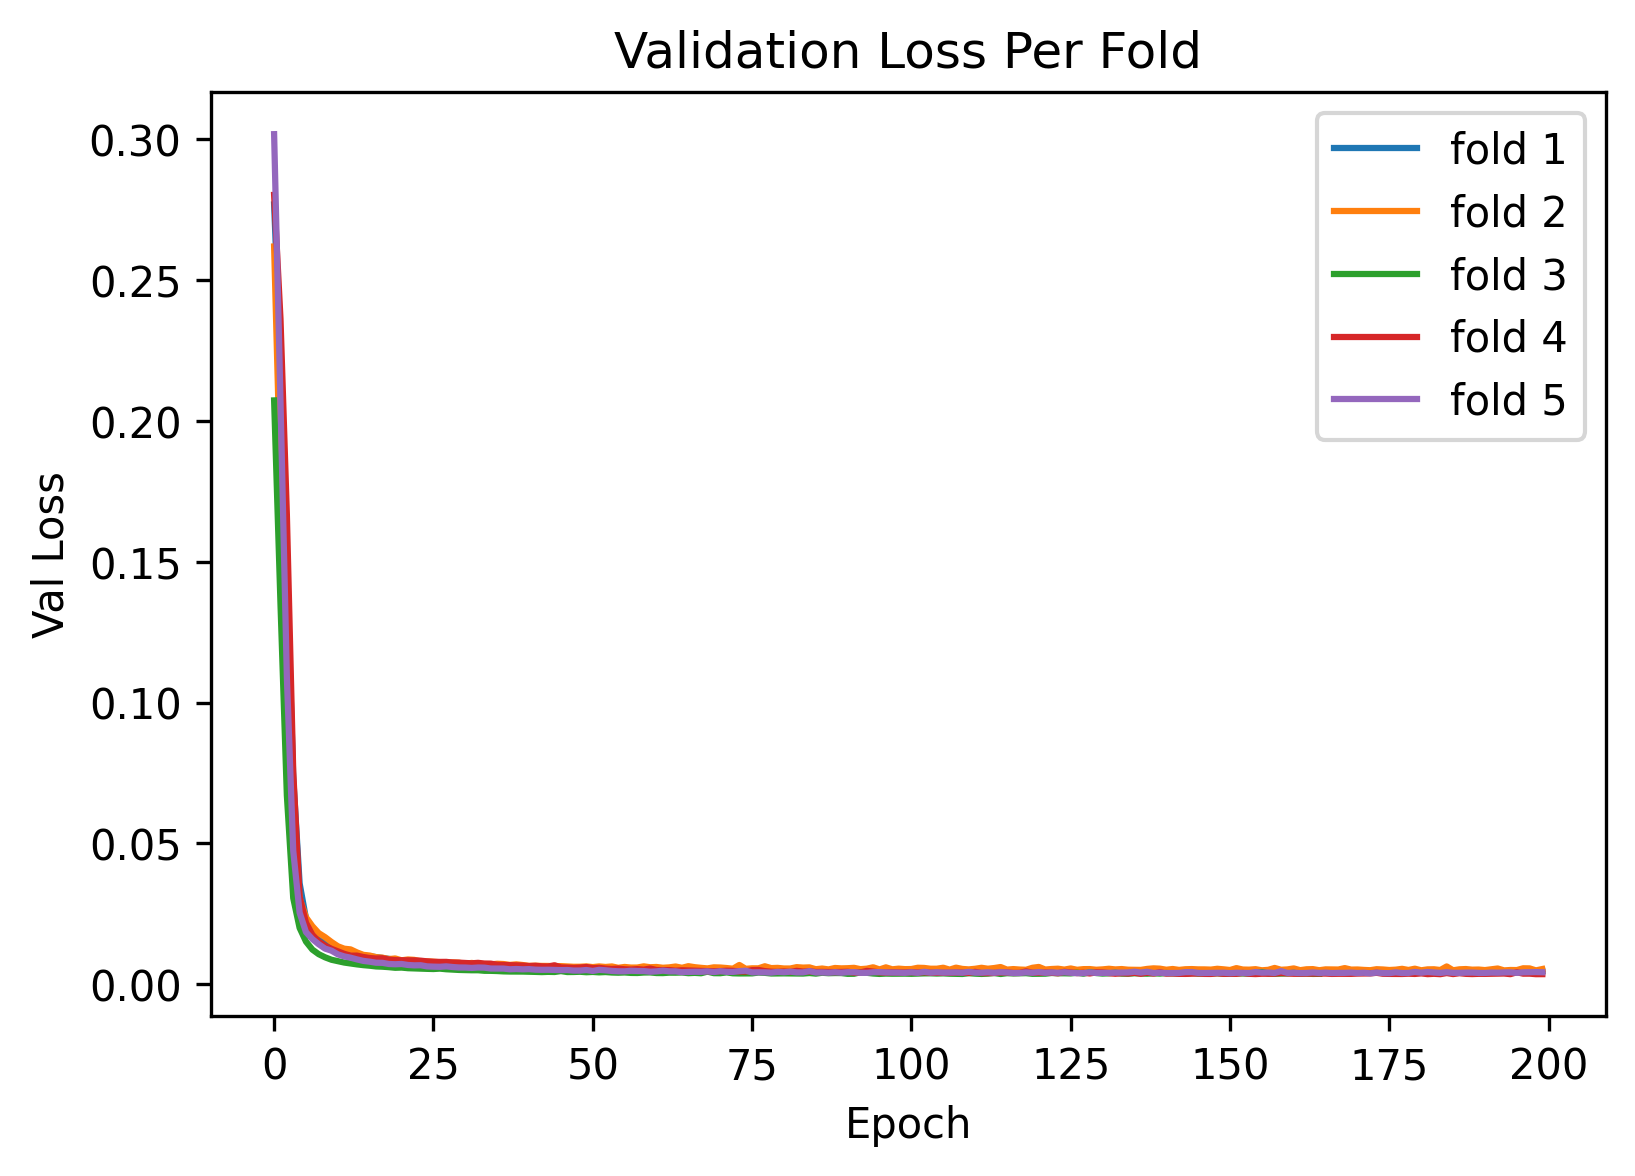

In [8]:
histories = result["histories"]

plt.figure()
for i, h in enumerate(histories):
    plt.plot(h["val_loss"], label=f"fold {i + 1}")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.title("Validation Loss Per Fold")
plt.legend()
plt.show()

## Best Validation Loss Per Fold

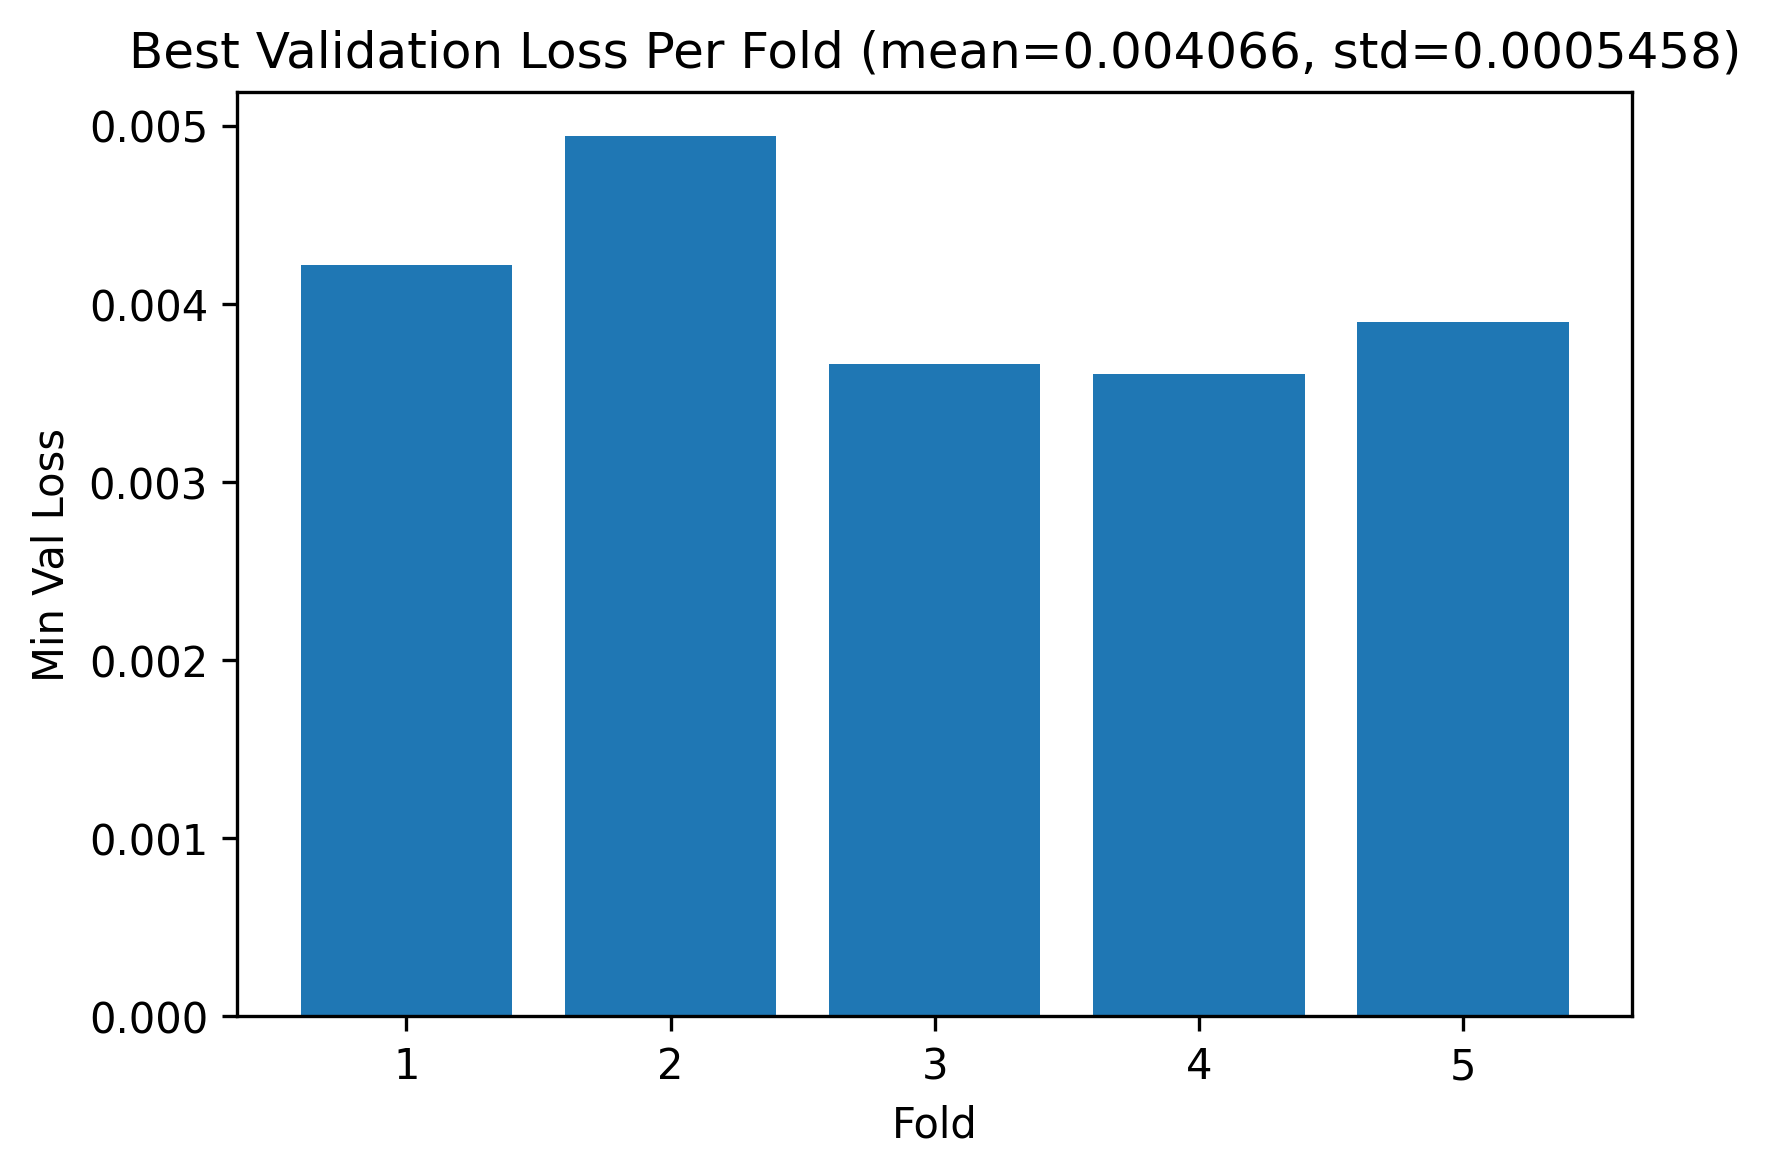

In [9]:
best_vals = np.array(result["fold_best_val"], dtype=float)
plt.figure()
plt.bar(np.arange(1, len(best_vals) + 1), best_vals)
plt.xlabel("Fold")
plt.ylabel("Min Val Loss")
plt.title(
    f"Best Validation Loss Per Fold (mean={result['mean_best_val']:.4g}, std={result['std_best_val']:.4g})"
)
plt.show()

## Predict Function

In [ ]:
def predict(params, model, X_mean, X_std, Y_mean=None, Y_std=None, normalize_Y=True):
    params = (params - X_mean) / X_std

    xb = torch.from_numpy(params).to(device)

    model.eval()
    with torch.no_grad():
        pred_norm = model(xb).cpu().numpy()

    if normalize_Y:
        pred_log = pred_norm * Y_std + Y_mean
    else:
        pred_log = pred_norm

    pred_dl = np.exp(pred_log)
    return pred_dl

## Percent Errors of Folds

In [11]:
X, Y, ell = load_training_arrays(H5_PATH)
device = torch.device("mps")

fold_pct_errors = []

for fold_idx in range(kcfg.k):
    fold_model = result["models"][fold_idx]
    fold_norm = result["norms"][fold_idx]
    val_indices = result["val_indices"][fold_idx]

    X_val = X[val_indices]
    Y_val = Y[val_indices]

    X_mean = fold_norm["X"].mean
    X_std = fold_norm["X"].std
    Y_mean = fold_norm["Y"].mean if dlcfg.normalize_Y else None
    Y_std = fold_norm["Y"].std if dlcfg.normalize_Y else None

    pred = predict(
        X_val, fold_model, X_mean, X_std, Y_mean, Y_std, normalize_Y=dlcfg.normalize_Y
    )
    true = np.exp(Y_val)

    pct_err = np.mean(np.abs((pred - true) / true)) * 100
    fold_pct_errors.append(pct_err)
    print(f"Fold {fold_idx + 1} % Error: {pct_err:.2f}%")

print()
print(f"CV Mean % Error: {np.mean(fold_pct_errors):.2f}%")
print(f"CV Std  % Error: {np.std(fold_pct_errors):.2f}%")

Fold 1 % Error: 4.97%
Fold 2 % Error: 5.20%
Fold 3 % Error: 4.63%
Fold 4 % Error: 4.52%
Fold 5 % Error: 4.86%

CV Mean % Error: 4.84%
CV Std  % Error: 0.24%
